In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import json
import os
from dotenv import load_dotenv
import anthropic
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file
load_dotenv('../.env')
api_key = os.getenv('ANTHROPIC_API_KEY')

if api_key:
    print("✅ Libraries loaded")
    print("✅ Anthropic API key loaded")
else:
    print("❌ API key not found — check your .env file")

plt.rcParams['figure.figsize'] = (14, 6)

c:\Users\user\Desktop\MY_PROJECTS OF MACHINE_LEARNING\loan portfolio risk intelligence system\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries loaded
✅ Anthropic API key loaded


In [2]:
# Load PD model
pd_model = lgb.Booster(model_file='../models/pd_model.txt')

# Load feature list
with open('../models/feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

# Load model dataset
df = pd.read_csv('../data/df_model_with_pricing.csv')

# Keep only feature columns
X = df[feature_cols].copy()

print(f"✅ Model loaded")
print(f"✅ Dataset shape: {df.shape}")
print(f"✅ Features: {feature_cols}")

✅ Model loaded
✅ Dataset shape: (1345350, 30)
✅ Features: ['int_rate', 'loan_to_income', 'fico_range_high', 'fico_range_low', 'installment_to_income', 'dti', 'loan_amnt', 'installment', 'annual_inc']


In [4]:
print("Computing SHAP values...")
print("(This may take 2-3 minutes on full dataset)")

# TreeSHAP — exact computation for tree models
explainer = shap.TreeExplainer(pd_model)

# Use a sample for SHAP computation — 5000 rows is enough
# Full dataset would take too long
sample_idx = np.random.choice(len(X), 5000)
X_sample = X.iloc[sample_idx].reset_index(drop=True)
df_sample = df.iloc[sample_idx].reset_index(drop=True)

shap_values = explainer.shap_values(X_sample)

print(f"✅ SHAP values computed")
print(f"   Shape: {shap_values.shape}")
print(f"   One row per sample, one column per feature")

Computing SHAP values...
(This may take 2-3 minutes on full dataset)
✅ SHAP values computed
   Shape: (5000, 9)
   One row per sample, one column per feature


Global Feature Importance (Mean |SHAP|):
              feature  mean_abs_shap
             int_rate       0.518619
       loan_to_income       0.175660
                  dti       0.120851
            loan_amnt       0.115255
          installment       0.114037
      fico_range_high       0.111068
installment_to_income       0.054502
           annual_inc       0.053498
       fico_range_low       0.028133


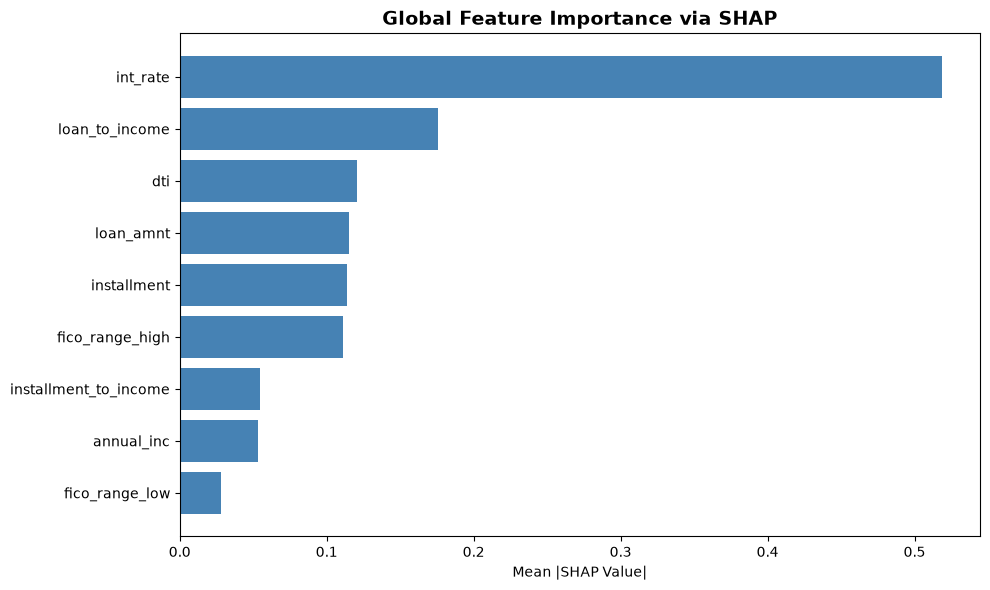

In [5]:
# Mean absolute SHAP value per feature
# Shows which features matter most overall across all predictions

mean_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Global Feature Importance (Mean |SHAP|):")
print(mean_shap.to_string(index=False))

# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(mean_shap['feature'][::-1],
         mean_shap['mean_abs_shap'][::-1],
         color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Global Feature Importance via SHAP',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/images/21_shap_importance.png', dpi=150)
plt.show()

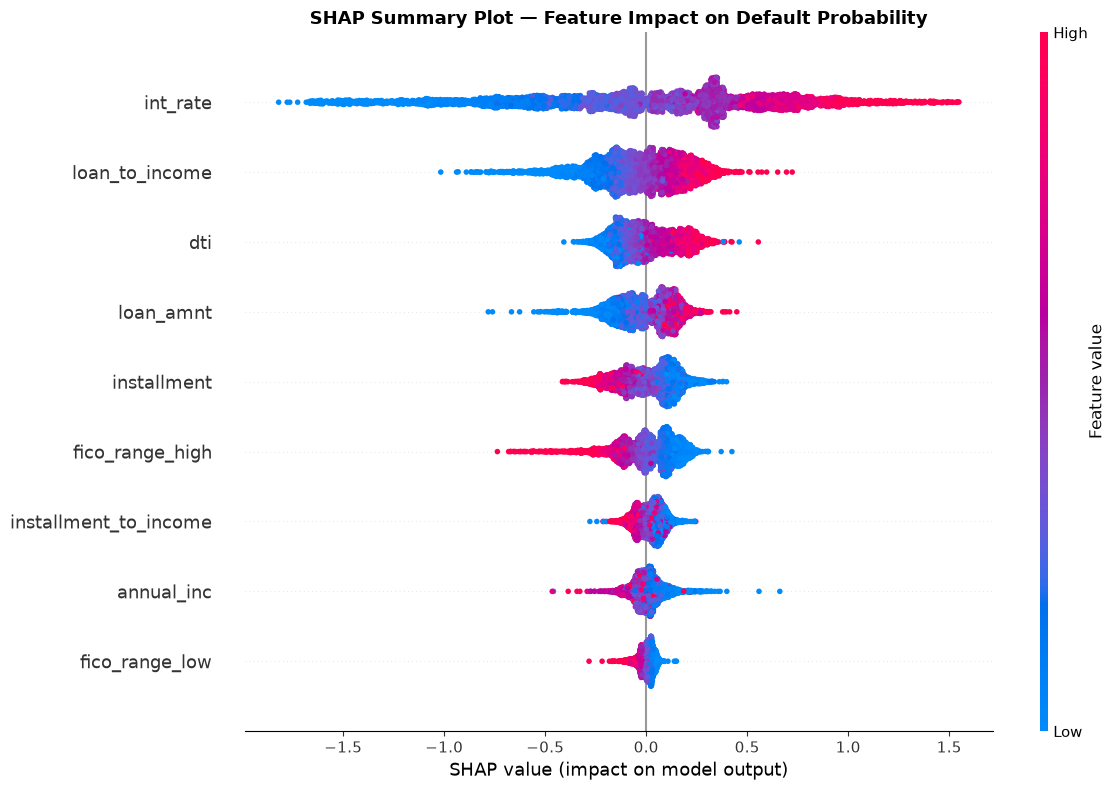

✅ SHAP summary plot saved


In [6]:
# Beeswarm plot — shows both importance AND direction
# Each dot is one customer
# Red = high feature value, Blue = low feature value
# X position = impact on default probability

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    show=False,
    plot_size=(12, 8)
)
plt.title('SHAP Summary Plot — Feature Impact on Default Probability',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/images/22_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved")

High risk customer index: 4023
Predicted default probability: 87.4%

Customer profile:
  int_rate: 24.9900
  loan_to_income: 0.4166
  fico_range_high: 664.0000
  fico_range_low: 660.0000
  installment_to_income: 0.1467
  dti: 37.8500
  loan_amnt: 10000.0000
  installment: 293.4600
  annual_inc: 24000.0000


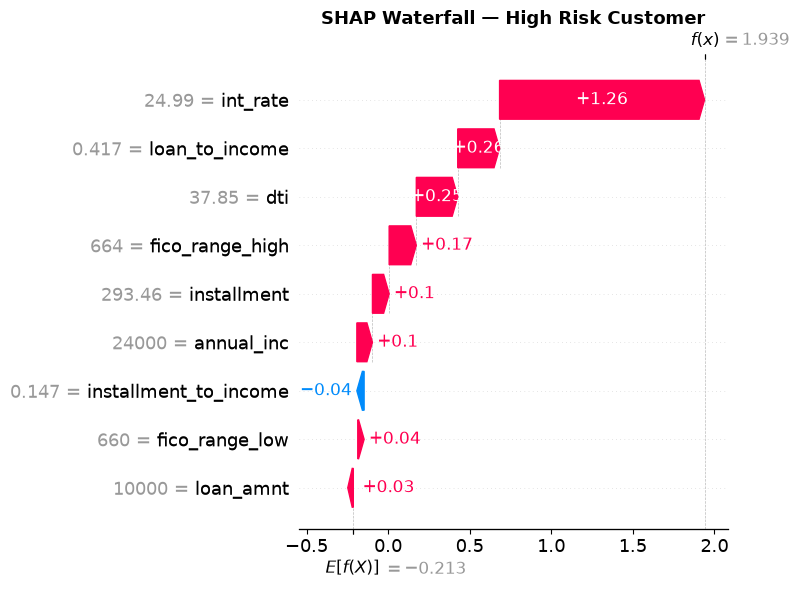

In [7]:
# Pick a high-risk customer — someone the model flagged as likely to default
# Find customer with highest predicted PD
predictions = pd_model.predict(X_sample)
high_risk_idx = np.argmax(predictions)

print(f"High risk customer index: {high_risk_idx}")
print(f"Predicted default probability: {predictions[high_risk_idx]*100:.1f}%")
print(f"\nCustomer profile:")
for feature in feature_cols:
    print(f"  {feature}: {X_sample.iloc[high_risk_idx][feature]:.4f}")

# Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[high_risk_idx].values,
    feature_names=feature_cols
)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall — High Risk Customer',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/images/23_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Get top 5 SHAP drivers for the denied customer
# These feed into the LLM credit memo

shap_for_customer = shap_values[high_risk_idx]

# Create feature contribution dataframe
feature_contributions = pd.DataFrame({
    'feature': feature_cols,
    'shap_value': shap_for_customer,
    'feature_value': X_sample.iloc[high_risk_idx].values,
    'abs_shap': np.abs(shap_for_customer)
}).sort_values('abs_shap', ascending=False)

# Top 5 drivers
top_drivers = feature_contributions.head(5)

print("Top 5 SHAP Drivers for Denied Customer:")
print("=" * 60)
for _, row in top_drivers.iterrows():
    direction = "↑ increases" if row['shap_value'] > 0 else "↓ decreases"
    print(f"  {row['feature']:<30} = {row['feature_value']:.4f}")
    print(f"    SHAP: {row['shap_value']:+.4f} — {direction} default risk")
    print()

Top 5 SHAP Drivers for Denied Customer:
  int_rate                       = 24.9900
    SHAP: +1.2564 — ↑ increases default risk

  loan_to_income                 = 0.4166
    SHAP: +0.2564 — ↑ increases default risk

  dti                            = 37.8500
    SHAP: +0.2539 — ↑ increases default risk

  fico_range_high                = 664.0000
    SHAP: +0.1664 — ↑ increases default risk

  installment                    = 293.4600
    SHAP: +0.1025 — ↑ increases default risk



In [11]:
# This is your differentiator
# Take SHAP values → pass to Claude → get plain language explanation
from groq import Groq
def generate_credit_memo(
    customer_data: dict,
    top_drivers: pd.DataFrame,
    predicted_pd: float,
    base_rate: float,
    api_key: str
) -> dict:
    """
    Generate a regulatory-style adverse action credit memo
    grounded strictly in SHAP attributions
    """

    # Format SHAP drivers for prompt
    drivers_text = ""
    for i, (_, row) in enumerate(top_drivers.iterrows(), 1):
        direction = "increases" if row['shap_value'] > 0 else "decreases"
        drivers_text += f"""
    {i}. Feature: {row['feature']}
       Customer value: {row['feature_value']:.4f}
       Impact: SHAP value of {row['shap_value']:+.4f} — {direction} default risk
       Absolute importance: {row['abs_shap']:.4f}
"""

    prompt = f"""You are a credit risk officer at a financial institution.
A loan application has been reviewed by our AI risk model and flagged 
for denial based on the following quantitative analysis.

MODEL OUTPUT:
- Predicted probability of default: {predicted_pd*100:.1f}%
- Portfolio average default rate: {base_rate*100:.1f}%
- Risk assessment: {'HIGH RISK' if predicted_pd > 0.25 else 'ELEVATED RISK'}

TOP RISK DRIVERS (from SHAP analysis):
{drivers_text}

FEATURE DEFINITIONS:
- int_rate: interest rate on the loan (%)
- loan_to_income: loan amount divided by annual income
- fico_range_high: upper bound of applicant FICO score range
- fico_range_low: lower bound of applicant FICO score range
- installment_to_income: monthly installment divided by monthly income
- dti: debt-to-income ratio (%)
- loan_amnt: requested loan amount ($)
- installment: monthly payment amount ($)
- inq_last_6mths: number of credit inquiries in last 6 months
- annual_inc: annual income ($)

YOUR TASK:
Generate a professional adverse action credit memo with this exact 
JSON structure. Base ALL explanations strictly on the SHAP values 
provided. Do not invent reasons not supported by the data.

Return ONLY valid JSON, no other text:
{{
    "decision": "DENIED",
    "predicted_pd_pct": {predicted_pd*100:.1f},
    "risk_level": "{'HIGH' if predicted_pd > 0.25 else 'ELEVATED'}",
    "primary_reasons": [
        {{
            "reason_code": "short code like HIGH_DTI",
            "feature": "feature name",
            "plain_language": "one sentence explanation a customer can understand",
            "severity": "HIGH or MEDIUM or LOW"
        }}
    ],
    "adverse_action_notice": "2-3 sentence plain English explanation suitable for sending to the applicant. Must reference specific financial factors. Must not mention the AI model.",
    "analyst_notes": "2-3 sentence technical summary for internal credit team referencing SHAP values and specific feature values",
    "recommendation": "what the applicant could do to improve their application"
}}"""

    client = anthropic.Anthropic(api_key=api_key)
    # client = Groq(api_key=os.getenv('GROQ_API_KEY'))

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1000,
        messages=[{"role": "user", "content": prompt}]
    )

    # Parse JSON response
    response_text = response.content[0].text.strip()

    # Clean any markdown formatting if present
    if '```json' in response_text:
        response_text = response_text.split('```json')[1].split('```')[0].strip()
    elif '```' in response_text:
        response_text = response_text.split('```')[1].split('```')[0].strip()

    memo = json.loads(response_text)
    return memo


# Generate memo for our denied customer
print("Generating LLM credit memo...")
print("Calling Claude API...\n")

customer_data = X_sample.iloc[high_risk_idx].to_dict()
base_rate = df_sample['target'].mean()

memo = generate_credit_memo(
    customer_data=customer_data,
    top_drivers=top_drivers,
    predicted_pd=predictions[high_risk_idx],
    base_rate=base_rate,
    api_key=api_key
)

print("✅ Credit memo generated\n")
print("=" * 60)
print("CREDIT MEMO")
print("=" * 60)
print(f"Decision:     {memo['decision']}")
print(f"Risk Level:   {memo['risk_level']}")
print(f"Predicted PD: {memo['predicted_pd_pct']}%")
print(f"\nPrimary Reasons:")
for i, reason in enumerate(memo['primary_reasons'], 1):
    print(f"  {i}. [{reason['severity']}] {reason['reason_code']}")
    print(f"     {reason['plain_language']}")
print(f"\nAdverse Action Notice:")
print(f"  {memo['adverse_action_notice']}")
print(f"\nAnalyst Notes:")
print(f"  {memo['analyst_notes']}")
print(f"\nRecommendation:")
print(f"  {memo['recommendation']}")
print("=" * 60)

Generating LLM credit memo...
Calling Claude API...

✅ Credit memo generated

CREDIT MEMO
Decision:     DENIED
Risk Level:   HIGH
Predicted PD: 87.4%

Primary Reasons:
  1. [HIGH] HIGH_INTEREST_RATE
     The interest rate on your requested loan is 24.99%, which significantly elevates the likelihood that the loan becomes unaffordable and results in missed payments.
  2. [MEDIUM] HIGH_LOAN_TO_INCOME
     The amount you are borrowing represents approximately 41.7% of your annual income, indicating the loan size is too large relative to your earnings.
  3. [MEDIUM] HIGH_DEBT_TO_INCOME
     Your current debt-to-income ratio is 37.85%, meaning a substantial portion of your income is already committed to existing debt obligations, leaving limited capacity for an additional loan payment.
  4. [MEDIUM] INSUFFICIENT_CREDIT_SCORE
     Your credit score of 664 falls below the threshold we require for this loan product, reflecting a higher historical likelihood of repayment difficulty.
  5. [LOW] H

In [12]:
# Generate memos for 3 different risk profiles
# High risk, medium risk, low risk

# Find three representative customers
high_risk_idx   = np.argmax(predictions)
low_risk_idx    = np.argmin(predictions)
medium_risk_idx = np.argmin(np.abs(predictions - predictions.mean()))

test_customers = {
    'High Risk':   high_risk_idx,
    'Medium Risk': medium_risk_idx,
    'Low Risk':    low_risk_idx
}

memos = {}

for risk_label, idx in test_customers.items():
    print(f"\nGenerating memo for {risk_label} customer...")
    
    # Get top drivers for this customer
    shap_for_this = shap_values[idx]
    drivers_for_this = pd.DataFrame({
        'feature': feature_cols,
        'shap_value': shap_for_this,
        'feature_value': X_sample.iloc[idx].values,
        'abs_shap': np.abs(shap_for_this)
    }).sort_values('abs_shap', ascending=False).head(5)

    try:
        memo = generate_credit_memo(
            customer_data=X_sample.iloc[idx].to_dict(),
            top_drivers=drivers_for_this,
            predicted_pd=predictions[idx],
            base_rate=base_rate,
            api_key=api_key
        )
        memos[risk_label] = memo
        print(f"  ✅ PD: {predictions[idx]*100:.1f}% — {memo['risk_level']}")
        print(f"  Decision: {memo['decision']}")
        print(f"  Top reason: {memo['primary_reasons'][0]['plain_language']}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

# Save all memos
with open('../data/sample_credit_memos.json', 'w') as f:
    json.dump(memos, f, indent=2)

print("\n✅ Sample memos saved to data/sample_credit_memos.json")


Generating memo for High Risk customer...
  ✅ PD: 87.4% — HIGH
  Decision: DENIED
  Top reason: The interest rate on your requested loan (24.99%) is very high, which significantly increases the likelihood that the loan payments will become unmanageable over time.

Generating memo for Medium Risk customer...
  ✅ PD: 46.3% — HIGH
  Decision: DENIED
  Top reason: Your requested loan amount is very high relative to your reported income, indicating the debt burden may be unmanageable given your current financial situation.

Generating memo for Low Risk customer...
  ✅ PD: 1.6% — ELEVATED
  Decision: DENIED
  Top reason: The interest rate associated with your loan request is unusually low relative to our portfolio benchmarks, which our credit assessment has flagged as a risk indicator in the context of your overall application profile.

✅ Sample memos saved to data/sample_credit_memos.json


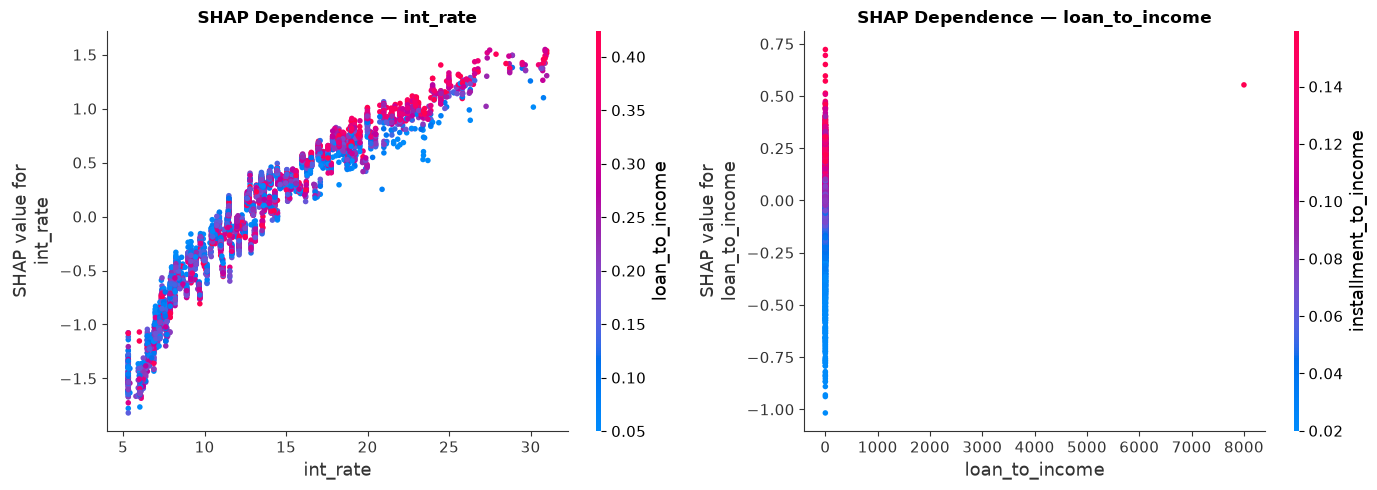

✅ SHAP dependence plots saved


In [13]:
# Shows relationship between one feature value
# and its SHAP impact across all customers
# Most important feature first

top_feature = mean_shap.iloc[0]['feature']
second_feature = mean_shap.iloc[1]['feature']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top feature dependence
shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample,
    ax=axes[0],
    show=False
)
axes[0].set_title(f'SHAP Dependence — {top_feature}',
                   fontweight='bold')

# Second feature dependence
shap.dependence_plot(
    second_feature,
    shap_values,
    X_sample,
    ax=axes[1],
    show=False
)
axes[1].set_title(f'SHAP Dependence — {second_feature}',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/images/24_shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP dependence plots saved")

In [14]:
# Save SHAP values for use in dashboard
shap_df = pd.DataFrame(
    shap_values,
    columns=[f'shap_{f}' for f in feature_cols]
)
shap_df['predicted_pd'] = predictions
shap_df.to_csv('../data/shap_values.csv', index=False)

# Save explainer expected value
with open('../models/shap_expected_value.json', 'w') as f:
    json.dump({'expected_value': explainer.expected_value}, f)

print("✅ SHAP values saved to data/shap_values.csv")
print("✅ Expected value saved to models/shap_expected_value.json")
print(f"\nSHAP base value (expected model output): {explainer.expected_value:.4f}")
print(f"This represents the average predicted PD across training data")
print(f"\n{'='*50}")
print("NOTEBOOK 7 COMPLETE")
print("='*50}")
print("""
What we built:
1. SHAP values for entire portfolio — global feature importance
2. Waterfall plot — individual prediction explanation  
3. Summary plot — feature impact distribution
4. Dependence plots — feature relationship analysis
5. LLM credit memo — plain language adverse action notice
6. Tested on 3 risk profiles — high, medium, low risk

This is the differentiator that separates LoanGuard
from every other credit risk portfolio project.
""")

✅ SHAP values saved to data/shap_values.csv
✅ Expected value saved to models/shap_expected_value.json

SHAP base value (expected model output): -0.2133
This represents the average predicted PD across training data

NOTEBOOK 7 COMPLETE
='*50}

What we built:
1. SHAP values for entire portfolio — global feature importance
2. Waterfall plot — individual prediction explanation  
3. Summary plot — feature impact distribution
4. Dependence plots — feature relationship analysis
5. LLM credit memo — plain language adverse action notice
6. Tested on 3 risk profiles — high, medium, low risk

This is the differentiator that separates LoanGuard
from every other credit risk portfolio project.

